# Instagram Usage EDA

Exploratory notebook: behavioral segmentation of a random sample of 10,000 users
(`random_state=42`). Its saved tables describe this notebook's sample only.
The main CLI, `src/pipeline.py`, fits the same feature transformations, PCA,
and KMeans on the **entire input dataset**. Its full-data results are documented
in [README](../README.md) and saved to `outputs/final_eda/`.
Further experiments: [separate_clusters_3D.ipynb](separate_clusters_3D.ipynb).


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

sns.set_theme(style="whitegrid")


## Load data

In [2]:
df = pd.read_csv('../data/raw/instagram_usage_lifestyle.csv')

print('rows:', len(df))
print('cols:', df.shape[1])

df.head(3)


rows: 1547896
cols: 58


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67


## Column pruning

In [3]:
df_work = df.copy()

# Drop columns not needed for behavioral segmentation at this stage
drop_cols = [
    "user_id",
    "app_name",
    "age",
    "gender",
    "country",
    "urban_rural",
    "employment_status",
    "education_level",
    "relationship_status",
    "has_children",
    "diet_quality",
    "smoking",
    "alcohol_frequency",
    "last_login_date",
]

df_work.drop(columns=drop_cols, inplace=True, errors='ignore')

print('rows:', len(df_work))
print('cols:', df_work.shape[1])


rows: 1547896
cols: 44


## Data validation

In [4]:
# Missing values
missing_pct = (
    df_work.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame('missing_pct')
)
missing_pct = missing_pct[missing_pct['missing_pct'] > 0]
missing_pct.head(15)


,missing_pct


In [5]:
# Duplicates
dup_count = df_work.duplicated().sum()
dup_count


np.int64(0)

In [6]:
# Numeric sanity checks
numeric_cols = df_work.select_dtypes(include=[np.number]).columns

neg_counts = (df_work[numeric_cols] < 0).sum().sort_values(ascending=False)
neg_counts = neg_counts[neg_counts > 0]
neg_counts.head(15)


Series([], dtype: int64)

In [7]:
zero_counts = (df_work[numeric_cols] == 0).sum().sort_values(ascending=False)
zero_counts.head(15)


linked_accounts_count         210638
ads_clicked_per_day            78729
hobbies_count                  77562
travel_frequency_per_year      77050
perceived_stress_score         37743
posts_created_per_week         34232
social_events_per_month        28482
notification_response_rate      7736
ads_viewed_per_day               527
volunteer_hours_per_month        312
comments_written_per_day         108
exercise_hours_per_week           99
books_read_per_year               57
weekly_work_hours                 49
dms_received_per_week             16
dtype: int64

## Sampling

Sample complete rows to keep `income_level` associated with the same user.
Use all rows if there are no more than 10,000. A fixed seed provides
repeatability, but does not establish cluster stability.


In [8]:
# Sample for faster iteration 
if len(df_work) > 10000:
    df_work = df_work.sample(n=10000, random_state=42).reset_index(drop=True)

print('rows:', len(df_work))


rows: 10000


## Feature engineering

Post-to-session and post-to-view ratios describe content creation relative to
consumption; `audience_ratio` compares followers with accounts followed.
The first two ratios combine weekly and daily measures: they are relative
indices, not literal posts per session. Adding 1 smooths the denominator.


In [9]:
df_work['creator_post_ratio'] = (
    df_work['posts_created_per_week'] / (df_work['sessions_per_day'] + 1)
)

df_work['broadcast_ratio'] = (
    df_work['posts_created_per_week'] /
    (df_work['stories_viewed_per_day'] + df_work['reels_watched_per_day'] + 1)
)

df_work['audience_ratio'] = (
    df_work['followers_count'] / (df_work['following_count'] + 1)
)

df_work[['creator_post_ratio', 'broadcast_ratio', 'audience_ratio']].describe().T


,count,mean,std,min,25%,50%,75%,max
creator_post_ratio,10000.0,0.731986,0.669720,0.000000,0.315789,0.535714,1.000000,7.000000
broadcast_ratio,10000.0,0.022398,0.013477,0.000000,0.013199,0.020280,0.028986,0.126761
audience_ratio,10000.0,0.900368,0.508664,0.399083,0.519118,0.717103,1.125737,6.211179


## Feature set

Use 10 activity measures and 3 derived ratios. IDs and demographics do not
contribute to distances: the objective is to describe behavior. Income is kept
only for subsequent group comparisons. Correlated features can increase the
contribution of overall activity.


In [10]:
activity_cols = [
    'user_engagement_score',
    'sessions_per_day',
    'daily_active_minutes_instagram',
    'average_session_length_minutes',
    'likes_given_per_day',
    'comments_written_per_day',
    'stories_viewed_per_day',
    'reels_watched_per_day',
    'time_on_feed_per_day',
    'time_on_reels_per_day',
]

creator_cols = [
    'creator_post_ratio',
    'broadcast_ratio',
    'audience_ratio',
]

XY = df_work[activity_cols + creator_cols]
XY.shape


(10000, 13)

## Scaling and PCA diagnostics

StandardScaler brings features onto a comparable scale. Two PCA components
retain approximately 72.14% of variance and provide an interpretable plane,
primarily reflecting activity and relative content creation. These labels are
approximate interpretations based on component weights. Some variation is
lost; the optimality of using two components has not been tested.


In [11]:
scaler = StandardScaler()
XY_scaled = scaler.fit_transform(XY)

pca_full = PCA().fit(XY_scaled)

var_df = pd.DataFrame({
    'component': np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    'explained_var': pca_full.explained_variance_ratio_,
})
var_df['cumulative_var'] = var_df['explained_var'].cumsum()

var_df.head(10)


,component,explained_var,cumulative_var
0,1,0.584757,0.584757
1,2,0.136632,0.721389
2,3,0.108273,0.829662
3,4,0.076905,0.906566
4,5,0.035752,0.942318
5,6,0.017527,0.959846
6,7,0.009417,0.969263
7,8,0.008955,0.978218
8,9,0.007406,0.985625
9,10,0.005604,0.991228


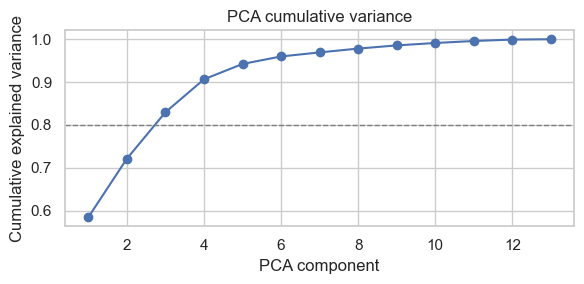

In [12]:
plt.figure(figsize=(6, 3))
plt.plot(var_df['component'], var_df['cumulative_var'], marker='o')
plt.axhline(0.8, color='gray', linestyle='--', linewidth=1)
plt.xlabel('PCA component')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative variance')
plt.tight_layout()
plt.show()


In [13]:
pca = PCA(n_components=2, random_state=42)
XY_pca = pca.fit_transform(XY_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=activity_cols + creator_cols,
    columns=['PCA1', 'PCA2']
)

loadings.sort_values('PCA1', ascending=False)


,PCA1,PCA2
daily_active_minutes_instagram,0.356660,0.091904
likes_given_per_day,0.350930,0.093270
time_on_feed_per_day,0.349829,0.092380
stories_viewed_per_day,0.347995,0.060745
comments_written_per_day,0.340914,0.092680
time_on_reels_per_day,0.338624,0.092663
reels_watched_per_day,0.318414,0.167258
sessions_per_day,0.280197,0.052674
average_session_length_minutes,0.069555,-0.073124
audience_ratio,-0.001342,0.018419


## Cluster selection

In [14]:
k_values = range(2, 11)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(XY_pca)

    rows.append({
        'k': k,
        'silhouette': silhouette_score(XY_pca, labels),
        'calinski_harabasz': calinski_harabasz_score(XY_pca, labels),
        'davies_bouldin': davies_bouldin_score(XY_pca, labels),
    })

metrics_df = pd.DataFrame(rows).set_index('k')
metrics_df


,silhouette,calinski_harabasz,davies_bouldin
k,,,
2,0.479071,12136.908434,0.776092
3,0.469468,13127.356301,0.733859
4,0.409357,13504.888959,0.780772
5,0.388854,13509.917835,0.817402
6,0.369581,13121.354552,0.846075
7,0.384090,12800.673519,0.809375
8,0.357412,12829.284170,0.856483
9,0.356107,12913.732050,0.827030
10,0.347219,12865.975747,0.846093


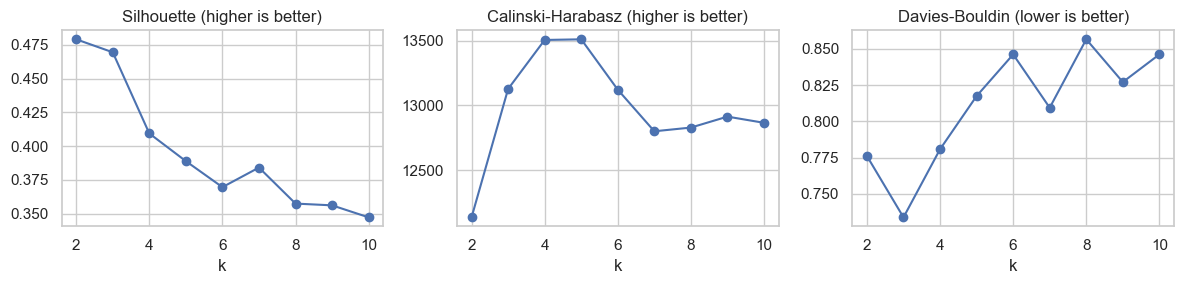

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

metrics_df['silhouette'].plot(ax=axes[0], marker='o')
axes[0].set_title('Silhouette (higher is better)')
axes[0].set_xlabel('k')

metrics_df['calinski_harabasz'].plot(ax=axes[1], marker='o')
axes[1].set_title('Calinski-Harabasz (higher is better)')
axes[1].set_xlabel('k')

metrics_df['davies_bouldin'].plot(ax=axes[2], marker='o')
axes[2].set_title('Davies-Bouldin (lower is better)')
axes[2].set_xlabel('k')

plt.tight_layout()
plt.show()


## Clustering

Keep `k=4` as a descriptive configuration with four behavioral profiles.
This is not a proven optimum: silhouette favors 2 groups, Davies-Bouldin favors
3, and Calinski-Harabasz favors 5 with a small advantage over 4. Metrics are
computed in PCA space. Segment stability and practical usefulness require
separate evaluation.


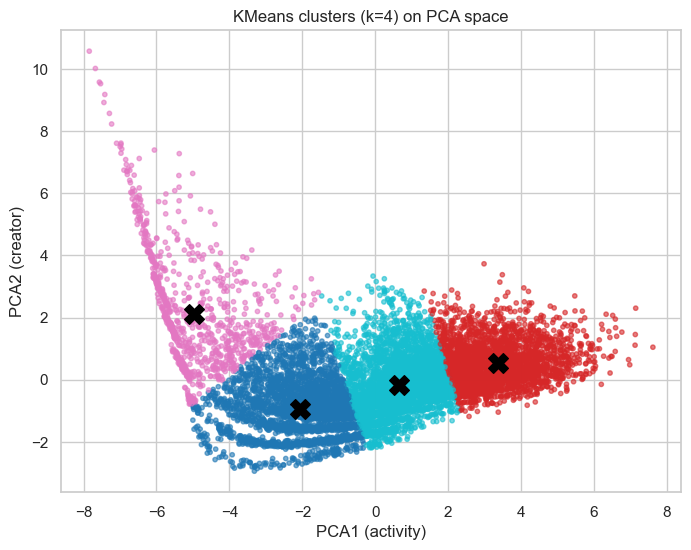

In [16]:
k = 4
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
labels = kmeans.fit_predict(XY_pca)

plt.figure(figsize=(8, 6))
plt.scatter(
    XY_pca[:, 0],
    XY_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=10,
    alpha=0.6,
)

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=200,
    marker='X',
)

plt.xlabel('PCA1 (activity)')
plt.ylabel('PCA2 (creator)')
plt.title(f'KMeans clusters (k={k}) on PCA space')
plt.show()


## Cluster profiles

In [17]:
df_seg = df_work.copy()
df_seg['cluster'] = labels

profile_cols = [
    'posts_created_per_week',
    'creator_post_ratio',
    'broadcast_ratio',
    'sessions_per_day',
    'daily_active_minutes_instagram',
]

groups = df_seg.groupby('cluster')
profiles = groups[profile_cols].mean()
profiles.insert(0, 'cluster_size', groups.size())
profiles.insert(1, 'cluster_share', profiles['cluster_size'] / len(df_seg))
profiles


,cluster_size,cluster_share,posts_created_per_week,creator_post_ratio,broadcast_ratio,sessions_per_day,daily_active_minutes_instagram
cluster,,,,,,,
0,3041,0.3041,3.376192,0.624700,0.018051,5.177573,96.071358
1,2601,0.2601,8.835832,0.531618,0.021477,18.564783,328.750096
2,945,0.0945,5.073016,2.081875,0.044855,1.453968,21.122751
3,3413,0.3413,6.528274,0.606514,0.020755,11.218576,208.715500


In [18]:
income_share = (
    df_seg
     .groupby('cluster')['income_level']
     .value_counts(normalize=True)
        .unstack()
)

income_order = ['Low', 'Lower-middle', 'Middle', 'Upper-middle', 'High']
income_share = income_share.reindex(columns=income_order)
income_share

income_level,Low,Lower-middle,Middle,Upper-middle,High
cluster,,,,,
0,0.200263,0.240381,0.307136,0.152253,0.099967
1,0.200692,0.256055,0.296040,0.145713,0.101499
2,0.196825,0.260317,0.293122,0.150265,0.099471
3,0.200117,0.243774,0.307647,0.145327,0.103135
